# Input / Target Pairs — Training & Validation Dataset

Visualize input (clean) and target (LA2A-processed) audio pairs from the SignalTrain LA2A dataset using the same dataloader as training.

**Dataset:** SignalTrain LA2A — each sample is `(input_audio, target_audio, params)` with `params` = (gain, ratio) from the hardware state.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project dataloader
from dataloader import DatasetConfig, create_dataloaders

In [2]:
# Dataset path — update to your SignalTrain LA2A root (parent of Train/Val/Test)
ROOT_DIR = "/home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1"

# Segment length for visualization (samples). Same as train_length for consistency.
VIS_LENGTH = 8192  # ~0.19 s at 44.1 kHz — short enough to see detail
SAMPLE_RATE = 44100
N_PARAMS = 2  # LA2A: gain, ratio

In [3]:
config = DatasetConfig(
    root_dir=ROOT_DIR,
    train_subset="Train",
    val_subset="Val",
    test_subset="Test",
    train_length=VIS_LENGTH,
    eval_length=VIS_LENGTH,
    sample_rate=SAMPLE_RATE,
    n_params=N_PARAMS,
    preload=False,
    half_precision=False,
    shuffle=True,
    batch_size=4,
    num_workers=0,  # 0 for notebook to avoid fork issues
    pin_memory=False,
)

train_loader, val_loader, _ = create_dataloaders(config)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

INFO:dataloader:Found 66 paired input/target files in Train subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Train
INFO:dataloader:Found 15 paired input/target files in Val subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Val
INFO:dataloader:Found 3 paired input/target files in Test subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Test
INFO:dataloader:Created dataloaders: train=66, val=15
INFO:dataloader:Test dataset size: 3


Train batches: 16, Val batches: 4


In [4]:
train_loader.dataset[2]

(tensor([[0.0717, 0.0723, 0.0760,  ..., 0.0032, 0.0011, 0.0023]]),
 tensor([[0.0777, 0.0764, 0.0793,  ..., 0.0044, 0.0006, 0.0006]]),
 tensor([-1.0000, -0.7000]))

## Visualize one batch (train or val)

In [5]:
def visualize_batch(input_audio, target_audio, params, sample_rate=44100, title_prefix="Sample"):
    """
    Plot input vs target waveforms for each item in the batch.
    input_audio, target_audio: (B, 1, T), params: (B, P)
    """
    B = input_audio.shape[0]
    T = input_audio.shape[2]
    t_sec = np.arange(T) / sample_rate

    # Find global min and max across all input and target waveforms for consistent y limits
    inp_min = input_audio[:, 0, :].min().item()
    inp_max = input_audio[:, 0, :].max().item()
    tgt_min = target_audio[:, 0, :].min().item()
    tgt_max = target_audio[:, 0, :].max().item()
    y_min = min(inp_min, tgt_min)
    y_max = max(inp_max, tgt_max)
    buffer = 0.05 * (y_max - y_min) if y_max > y_min else 0.1  # handle constant signals
    y_lower = y_min - buffer
    y_upper = y_max + buffer

    fig, axes = plt.subplots(B, 2, figsize=(12, 2.5 * B), squeeze=False)
    for i in range(B):
        inp = input_audio[i, 0].numpy()
        tgt = target_audio[i, 0].numpy()
        p = params[i].numpy()
        param_str = ", ".join(f"p{j}={p[j]:.1f}" for j in range(len(p)))
        
        axes[i, 0].plot(t_sec, inp, color="#2e86ab", alpha=0.9, linewidth=0.8)
        axes[i, 0].set_ylabel("Input")
        axes[i, 0].set_title(f"{title_prefix} {i} — Input (clean)")
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].set_xlim(0, t_sec[-1])
        axes[i, 0].set_ylim(y_lower, y_upper)
        
        axes[i, 1].plot(t_sec, tgt, color="#e94f37", alpha=0.9, linewidth=0.8)
        axes[i, 1].set_ylabel("Target")
        axes[i, 1].set_title(f"{title_prefix} {i} — Target (LA2A) [{param_str}]")
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].set_xlim(0, t_sec[-1])
        axes[i, 1].set_ylim(y_lower, y_upper)
    
    for ax in axes[:, 0]:
        ax.set_xlabel("Time (s)")
    for ax in axes[:, 1]:
        ax.set_xlabel("Time (s)")
    plt.tight_layout()
    return fig

Shapes: input torch.Size([4, 1, 8192]), target torch.Size([4, 1, 8192]), params torch.Size([4, 2])


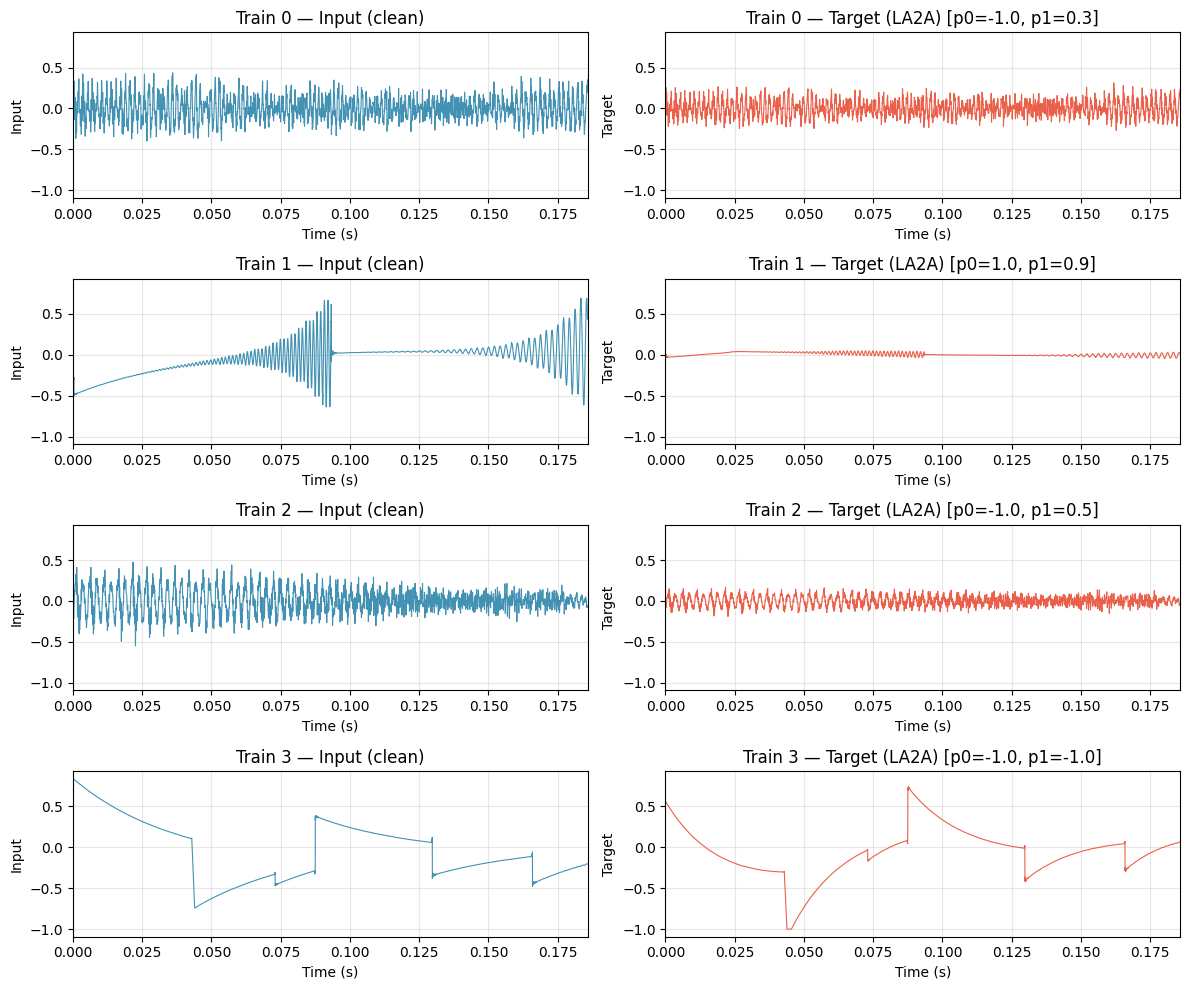

In [6]:
# Get one batch from training set
batch = next(iter(train_loader))
input_audio, target_audio, params = batch
print(f"Shapes: input {input_audio.shape}, target {target_audio.shape}, params {params.shape}")

fig = visualize_batch(input_audio, target_audio, params, sample_rate=SAMPLE_RATE, title_prefix="Train")
plt.show()

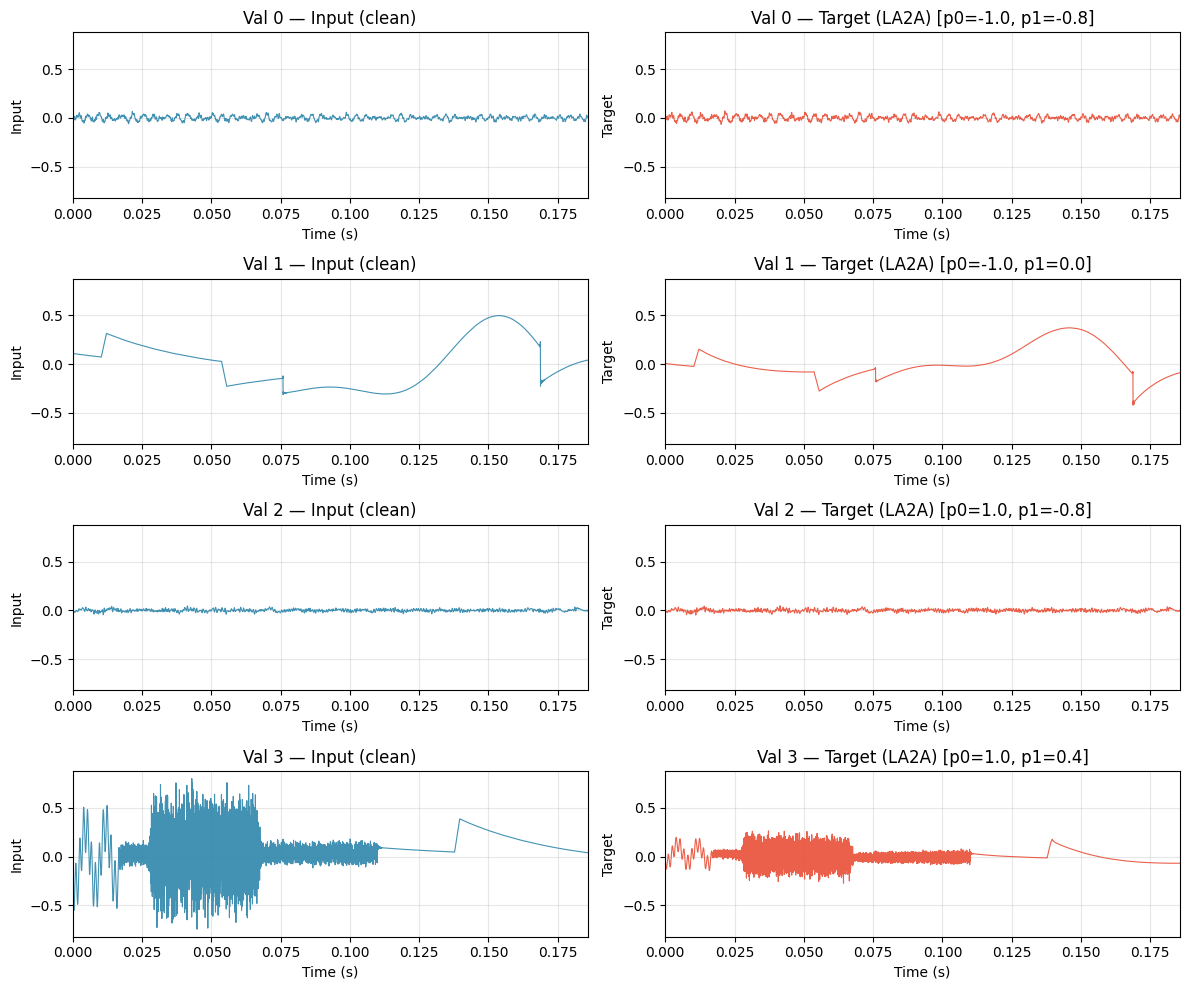

In [7]:
# Get one batch from validation set
batch_val = next(iter(val_loader))
input_audio_v, target_audio_v, params_v = batch_val

fig = visualize_batch(input_audio_v, target_audio_v, params_v, sample_rate=SAMPLE_RATE, title_prefix="Val")
plt.show()

## Overlay: input vs target (single sample)

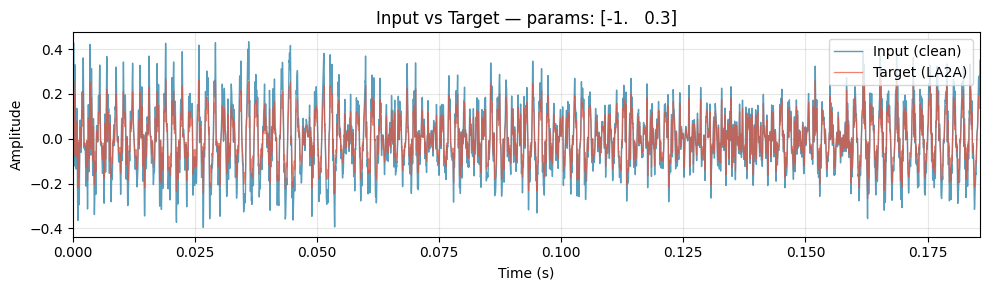

In [8]:
def plot_input_target_overlay(input_audio, target_audio, params, sample_rate=44100, sample_idx=0):
    """Single sample: overlay input and target in one plot."""
    inp = input_audio[sample_idx, 0].numpy()
    tgt = target_audio[sample_idx, 0].numpy()
    p = params[sample_idx].numpy()
    T = inp.shape[0]
    t_sec = np.arange(T) / sample_rate
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(t_sec, inp, color="#2e86ab", alpha=0.8, label="Input (clean)", linewidth=1)
    ax.plot(t_sec, tgt, color="#e94f37", alpha=0.7, label="Target (LA2A)", linewidth=0.9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Input vs Target — params: {p}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_sec[-1])
    plt.tight_layout()
    return fig

# Use last train batch
plot_input_target_overlay(input_audio, target_audio, params, sample_rate=SAMPLE_RATE, sample_idx=0)
plt.show()

## Optional: load from YAML config

In [9]:
# Uncomment and run if you want to use config.train_step_by_step.yaml
# import yaml
# with open("config.train_step_by_step.yaml") as f:
#     cfg = yaml.safe_load(f)
# ds = cfg.get("dataset", {})
# config = DatasetConfig(
#     root_dir=ds.get("root_dir", ROOT_DIR),
#     train_subset=ds.get("train_subset", "Train"),
#     val_subset=ds.get("val_subset", "Val"),
#     test_subset=ds.get("test_subset", "Test"),
#     train_length=ds.get("train_length", VIS_LENGTH),
#     eval_length=ds.get("eval_length", VIS_LENGTH),
#     sample_rate=ds.get("sample_rate", 44100),
#     n_params=ds.get("n_params", 2),
#     preload=ds.get("preload", False),
#     half_precision=ds.get("half_precision", False),
#     shuffle=True,
#     batch_size=ds.get("batch_size", 4),
#     num_workers=0,
#     pin_memory=False,
# )
# train_loader, val_loader, _ = create_dataloaders(config)